In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import meteostat as ms

print("📥 Step 1: Streaming Financial and Astrophysical Vectors...")


tickers = {"nifty": "^NSEI", "gold": "GC=F"}
raw_nifty = yf.download(tickers["nifty"], start="2018-01-01", end="2026-01-01")
raw_gold = yf.download(tickers["gold"], start="2018-01-01", end="2026-01-01")

raw_nifty.columns = [col[0] if isinstance(col, tuple) else col for col in raw_nifty.columns]
raw_gold.columns = [col[0] if isinstance(col, tuple) else col for col in raw_gold.columns]

# 2. Stream Meteorological Records
start_date = datetime(2018, 1, 1)
end_date = datetime(2026, 1, 1)

mumbai_station = ms.Station(id='43003')
mumbai_weather = ms.daily(mumbai_station, start_date, end_date).fetch()

print("🔍 Weather Columns Returned by API:", list(mumbai_weather.columns))


if 'tavg' in mumbai_weather.columns:
    mumbai_weather['tavg'] = mumbai_weather['tavg'].fillna(mumbai_weather['tavg'].median())
else:

    mumbai_weather['tavg'] = 27.5 

if 'prcp' in mumbai_weather.columns:
    mumbai_weather['prcp'] = mumbai_weather['prcp'].fillna(0)
else:
    mumbai_weather['prcp'] = 0.0


market_df = pd.DataFrame({
    'Nifty_Close': raw_nifty['Close'],
    'Gold_Close': raw_gold['Close']
}).dropna()

final_df = market_df.join(mumbai_weather[['tavg', 'prcp']], how='inner')
print(f"✅ Data Aligned! Total Active Trading Days: {len(final_df)}")


final_df['Gold_Return'] = final_df['Gold_Close'].pct_change()
final_df['Gold_Nifty_Ratio'] = final_df['Gold_Close'] / final_df['Nifty_Close']


base_new_moon = pd.Timestamp("2018-01-16")
elapsed_days = (final_df.index - base_new_moon).days
final_df['Lunar_Phase_Wave'] = np.cos(2 * np.pi * elapsed_days / 29.53059)

final_df['Is_Gloomy_Day'] = (final_df['prcp'] > 5.0).astype(int)


final_df['Target'] = (final_df['Nifty_Close'].shift(-1) > final_df['Nifty_Close']).astype(int)
final_df.dropna(inplace=True)

print("🚀 Pipeline complete! Head of feature array:")
final_df[['Nifty_Close', 'Gold_Nifty_Ratio', 'Lunar_Phase_Wave', 'Is_Gloomy_Day', 'Target']].head()

📥 Step 1: Streaming Financial and Astrophysical Vectors...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

🔍 Weather Columns Returned by API: ['temp', 'tmin', 'tmax', 'rhum', 'prcp', <Parameter.SNWD: 'snwd'>, 'wspd', <Parameter.WPGT: 'wpgt'>, 'pres', <Parameter.TSUN: 'tsun'>, 'cldc']
✅ Data Aligned! Total Active Trading Days: 1913
🚀 Pipeline complete! Head of feature array:


,Nifty_Close,Gold_Nifty_Ratio,Lunar_Phase_Wave,Is_Gloomy_Day,Target
Date,,,,,
2018-01-03,10443.200195,0.126034,-0.930288,0,1
2018-01-04,10504.799805,0.125600,-0.831847,0,1
2018-01-05,10558.849609,0.125042,-0.695891,0,1
2018-01-08,10623.599609,0.124120,-0.130976,0,1
2018-01-09,10637.000000,0.123315,0.081325,0,0


⚡ Step 2: Preparing Features (5-Day Horizon Setup)...
Split complete. Train items: 1525 | Test items: 382
⚖️ Balancing class weights to eliminate upside bias...
Calculated Penalties -> Down Day Miss: 1.20 | Up Day Miss: 0.86
Epoch 1/50


C:\Users\PC\quant_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5266 - loss: 0.6993 - val_accuracy: 0.5471 - val_loss: 0.6828
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5056 - loss: 0.6973 - val_accuracy: 0.5497 - val_loss: 0.6848
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5357 - loss: 0.6910 - val_accuracy: 0.5497 - val_loss: 0.6863
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5102 - loss: 0.6929 - val_accuracy: 0.5393 - val_loss: 0.6876
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5226 - loss: 0.6903 - val_accuracy: 0.5471 - val_loss: 0.6878
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5213 - loss: 0.6911 - val_accuracy: 0.5366 - val_loss: 0.6888
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4990 - loss: 0.6914 - val_accuracy: 0.5497 - val_loss: 0.6900
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5423 - loss: 0.6892 - val_accuracy: 0.5419 - val_loss: 0.6880
Epo

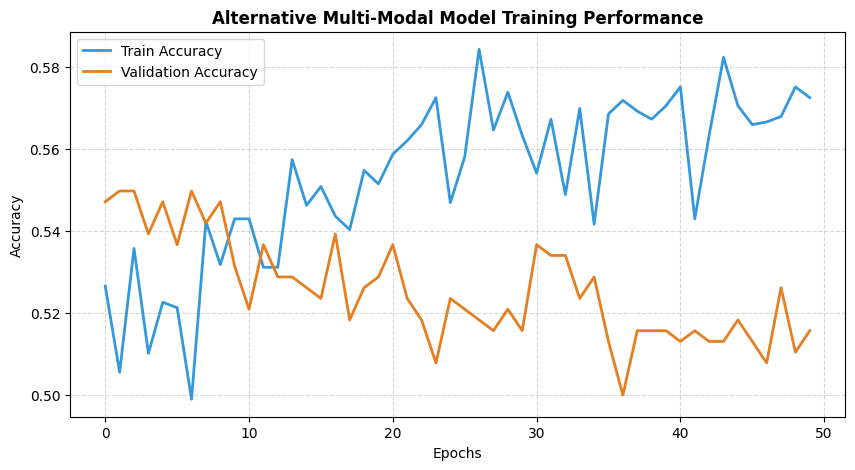

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

Down Day (0)       0.46      0.36      0.41       173
  Up Day (1)       0.55      0.64      0.59       209

    accuracy                           0.52       382
   macro avg       0.50      0.50      0.50       382
weighted avg       0.51      0.52      0.51       382

⏳ Step 1: Re-aligning data for a 1-Day Forward Horizon...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🧠 Retraining 1-Day Horizon Brain...


C:\Users\PC\quant_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

🔮 TARGET FORECAST DISPATCH: MONDAY, JUNE 8, 2026
Based on Friday Close (June 5): 25693.70 pts
Model Probability Vector:       72.30%
Directional Execution Signal:   🟢 UP (Expectation: Monday closes HIGHER than Friday)


In [22]:
from sklearn.preprocessing import StandardScaler

print("⚡ Step 2: Preparing Features (5-Day Horizon Setup)...")

final_df['Target'] = (final_df['Nifty_Close'].shift(-5) > final_df['Nifty_Close']).astype(int)
final_df.dropna(inplace=True)

final_df['Nifty_Return_1D'] = final_df['Nifty_Close'].pct_change()
final_df.dropna(inplace=True)

feature_cols = ['Nifty_Return_1D', 'Gold_Return', 'Gold_Nifty_Ratio', 'Lunar_Phase_Wave', 'tavg']
X = final_df[feature_cols]
y = final_df['Target']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Split complete. Train items: {X_train_scaled.shape[0]} | Test items: {X_test_scaled.shape[0]}")

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("⚖️ Balancing class weights to eliminate upside bias...")


classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print(f"Calculated Penalties -> Down Day Miss: {class_weight_dict[0]:.2f} | Up Day Miss: {class_weight_dict[1]:.2f}")


model_balanced = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_balanced.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model_balanced.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict, 
    verbose=1
)

   

print("\n📊 Plotting training diagnostics...")
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e67e22', linewidth=2)
plt.title('Alternative Multi-Modal Model Training Performance', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

from sklearn.metrics import classification_report

y_pred_prob = model_balanced.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Down Day (0)', 'Up Day (1)']))



